# Geospatial Data Science - EEPS 440/460

# Lecture 13

# Vector data

---

## Introduction

Vector data is a fundamental concept in Geographic Information Systems (GIS) and geospatial data science. It represents geographic features using points, lines, and polygons, making it essential for various spatial analyses, mapping, and decision-making processes. This lecture will introduce vector data, its structure, manipulation, and common applications using Python.

## What is Vector Data?

Vector data models spatial features using three primary geometries:

* **Points**: Represent discrete locations (e.g., cities, landmarks, or sensor locations).

* **Lines**: Represent linear features (e.g., roads, rivers, or boundaries).

* **Polygons**: Represent area-based features (e.g., lakes, administrative boundaries, or land use areas).

Each vector feature has associated attributes stored in a table, providing descriptive information about the feature.



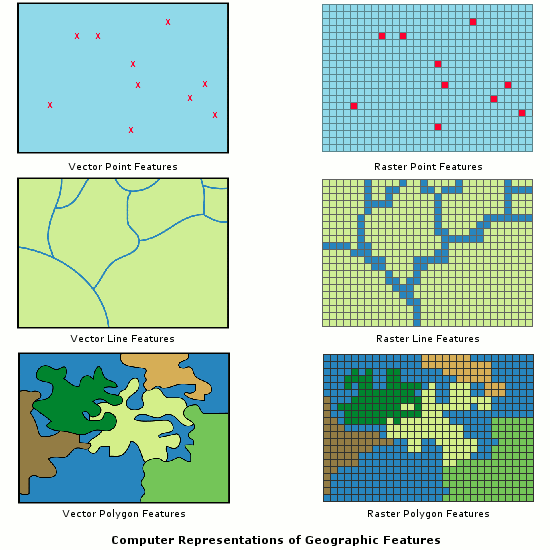

* Shapefiles and geodatabases are vector databases
* For each polygon, there are a set of attributes/properties
* Not as easy as regular grid datasets. However, they do have their place.

# Vector file formats

In [33]:
%%HTML
<iframe src='https://gdal.org/drivers/vector/index.html', width=700, height=600></iframe>

## Vector Data Formats
Common file formats for vector data include:
- **Shapefiles (.shp)**: A widely used format in GIS.
- **GeoJSON (.geojson)**: A JSON-based format used for web applications.
- **KML (.kml)**: Used for visualization in applications like Google Earth.
- **GPKG (.gpkg)**: A modern, SQLite-based geospatial format, storage efficient

## Working with Vector Data in Python
Python provides several libraries for handling vector data:
- **Geopandas**: Extends Pandas to handle spatial data.
- **Shapely**: Provides geometric operations.
- **Fiona**: Handles reading and writing of vector files.
- **Pyproj**: Performs coordinate transformations.


# Vector data example: HydroLakes

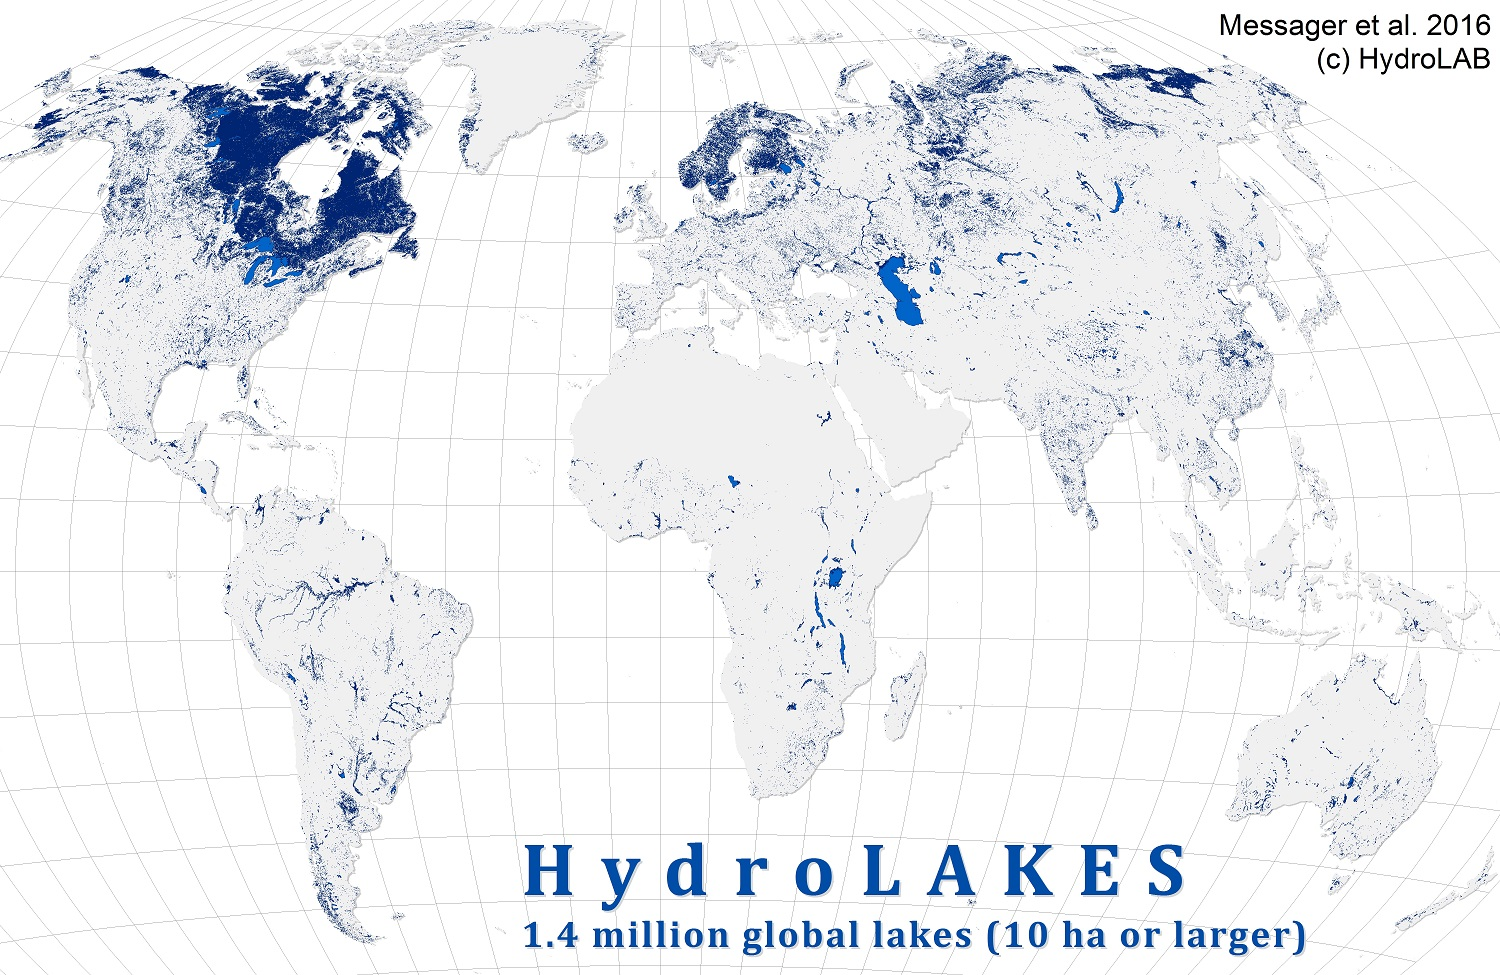

The data is saved as polygons not a regular grid. You can then save/access attributes per polygon.

# There is more to GDAL than you thought...

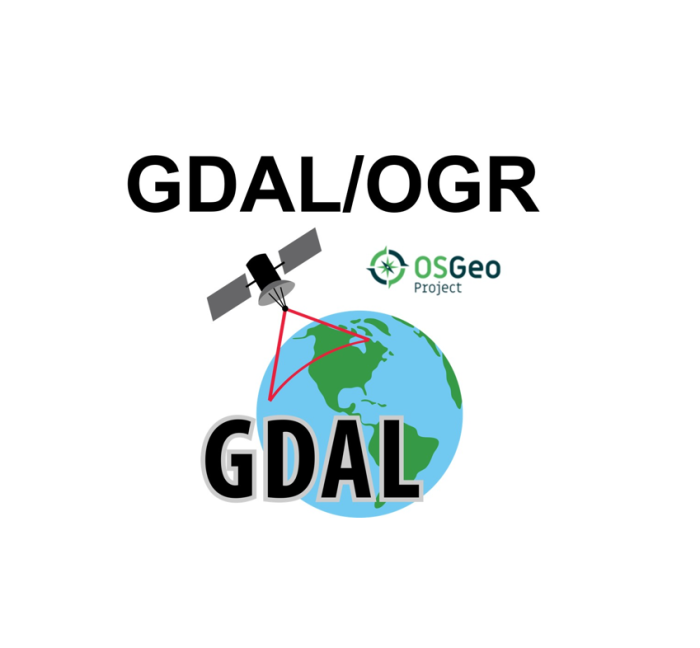

In [34]:
# Setup PROJ enviroment - usually you dont need to do this, but in case your installation cannot find PROJ you can try something like this:
import os
os.environ["PROJ_LIB"] = "/opt/conda/share/proj"

# ogrinfo

General information about a vector database

In [35]:
%%HTML
<iframe src='https://gdal.org/programs/ogrinfo.html', width=700, height=600></iframe>

In [ ]:
%%bash
ogrinfo -so /scratch/eeps440/data/HydroLakes/HydroLAKES_polys_v10.gdb HydroLAKES_polys_v10

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


INFO: Open of `../data/HydroLakes/HydroLAKES_polys_v10.gdb'
      using driver `OpenFileGDB' successful.

Layer name: HydroLAKES_polys_v10
Geometry: Multi Polygon
Feature Count: 1427688
Extent: (-180.000000, -55.865139) - (180.000000, 83.575951)
Layer SRS WKT:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodeti

# OGR formats

In [37]:
%%HTML
<iframe src='https://gdal.org/drivers/vector/index.html', width=700, height=600></iframe>

# Let's look at lakes around Houston

In [ ]:
%%bash 
ogrinfo -so -spat -95 29 -94 30. /scratch/eeps440/data/HydroLakes/HydroLAKES_polys_v10.gdb HydroLAKES_polys_v10

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


INFO: Open of `../data/HydroLakes/HydroLAKES_polys_v10.gdb'
      using driver `OpenFileGDB' successful.

Layer name: HydroLAKES_polys_v10
Geometry: Multi Polygon
Feature Count: 132
Extent: (-180.000000, -55.865139) - (180.000000, 83.575951)
Layer SRS WKT:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic la

# ogr2ogr

Alter an existing vector database (e.g., subset or reproject) 

In [39]:
%%HTML
<iframe src='https://gdal.org/programs/ogr2ogr.html', width=700, height=600></iframe>

# Let's create a new shapefile with the data around Houston

In [ ]:
%%bash 
ogr2ogr -spat -95.9 29.2 -94.9 30.2 ../Workspace/HydroLakes_Houston.shp /scratch/eeps440/data/HydroLakes/HydroLAKES_polys_v10.gdb

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device
Warning 6: Normalized/laundered field name: 'Shape_Length' to 'Shape_Leng'


# gdal_rasterize

Rasterize a vector database

In [41]:
%%HTML
<iframe src='https://gdal.org/programs/gdal_rasterize.html', width=700, height=600></iframe>

# Let's rasterize the polygons

* We will set each rasterized polygon to the lake id value

In [42]:
%%bash 
ogrinfo -so ../Workspace/HydroLakes_Houston.shp HydroLakes_Houston

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


INFO: Open of `../Workspace/HydroLakes_Houston.shp'
      using driver `ESRI Shapefile' successful.

Layer name: HydroLakes_Houston
Metadata:
  DBF_DATE_LAST_UPDATE=2025-04-08
Geometry: Polygon
Feature Count: 104
Extent: (-95.900388, 29.193750) - (-94.897319, 30.200962)
Layer SRS WKT:
GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["latitude",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["longitude",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    ID["EPSG",4326]]
Data axis to CRS axis mapping: 2,1
Hylak_id: Integer (9.0)
Lake_name: String (40.0)
Country: String (35.0)
Continent: String (15.0)
Poly_src: String (10.0)
Lake_type: Integer (9.0)
Grand_id: Integer (9.0)
Lake_area: Real (24.15)
Shore_len

In [43]:
%%bash 
gdal_rasterize -l HydroLakes_Houston -a Hylak_id -tr 0.001 0.001 \
../Workspace/HydroLakes_Houston.shp ../Workspace/HydroLakes_Houston_Hylak_id.tif

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


0...10...20...30...40...50...60...70...80...90...100 - done.


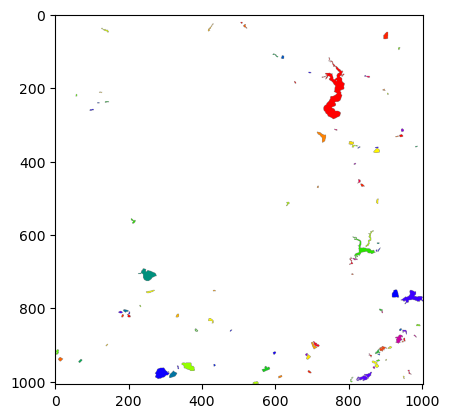

In [44]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
data = rasterio.open('../Workspace/HydroLakes_Houston_Hylak_id.tif').read(1)
#Reorder from 1 to nlakes
ulakes = np.unique(data)[1:]
for ilake in range(ulakes.size):
    data[data == ulakes[ilake]] = ilake+1
#Mask out non-lake area
data = np.ma.masked_array(data,data==0)
plt.imshow(data,cmap='prism')
plt.show()

# gdal_polygonize

Polygonize a raster

In [45]:
%%HTML
<iframe src='https://gdal.org/programs/gdal_polygonize.html', width=700, height=600></iframe>

# Let's polygonize our raster data again

In [46]:
%%bash
# run poligonize with option for 8 directional conectedness
gdal_polygonize.py -overwrite -8 ../Workspace/HydroLakes_Houston_Hylak_id.tif ../Workspace/HydroLakes_Houston_Hylak_id_Reproduced.shp

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


0...10...20...30...40...50...60...70...80...90...100 - done.


In [47]:
%%bash 
ogrinfo -so ../Workspace/HydroLakes_Houston_Hylak_id_Reproduced.shp HydroLakes_Houston_Hylak_id_Reproduced

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


INFO: Open of `../Workspace/HydroLakes_Houston_Hylak_id_Reproduced.shp'
      using driver `ESRI Shapefile' successful.

Layer name: HydroLakes_Houston_Hylak_id_Reproduced
Metadata:
  DBF_DATE_LAST_UPDATE=2025-04-08
Geometry: Polygon
Feature Count: 106
Extent: (-95.899888, 29.193462) - (-94.896888, 30.200462)
Layer SRS WKT:
GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["latitude",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["longitude",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    ID["EPSG",4326]]
Data axis to CRS axis mapping: 2,1
DN: Integer (9.0)


# Vector data in Python

There are many ways... We will use GeoPandas.

In [48]:
%%HTML
<iframe src='https://geopandas.org/', width=700, height=600></iframe>

# Read in vector data

In [49]:
import geopandas as gpd

#Open access to the file
fp = gpd.read_file('../Workspace/HydroLakes_Houston.shp')

In [50]:
#Display the data
fp.head()

,Hylak_id,Lake_name,Country,Continent,Poly_src,Lake_type,Grand_id,Lake_area,Shore_len,Shore_dev,...,Dis_avg,Res_time,Elevation,Slope_100,Wshd_area,Pour_long,Pour_lat,Shape_Leng,Shape_Area,geometry
0,9540,None,United States of America,North America,SWBD,2,1300,37.299999,71.370003,3.30,...,78.872002,51.000000,15,1.70,7231.000000,-95.132778,29.920584,0.686649,0.003482,"POLYGON ((-95.15217 30.07142, -95.14963 30.071..."
1,113900,None,United States of America,North America,SWBD,1,0,1.960000,5.880000,1.19,...,4.539000,7.100000,29,0.59,328.399994,-95.001615,30.147411,0.055945,0.000183,"POLYGON ((-94.99789 30.13413, -95.00238 30.133..."
2,113997,None,United States of America,North America,SWBD,1,0,2.980000,9.260000,1.51,...,0.499000,98.800003,14,0.51,29.799999,-95.169906,29.853577,0.088528,0.000278,"POLYGON ((-95.17035 29.87253, -95.16674 29.871..."
3,114011,None,United States of America,North America,SWBD,1,0,1.470000,4.680000,1.09,...,0.099000,161.600006,12,0.40,5.600000,-95.031156,29.826986,0.045879,0.000137,"POLYGON ((-95.02542 29.82389, -95.03095 29.823..."
4,114108,None,United States of America,North America,SWBD,1,0,1.820000,13.990000,2.92,...,0.852000,86.500000,-1,1.75,47.599998,-95.052083,29.569917,0.133075,0.000170,"POLYGON ((-95.03774 29.60827, -95.04214 29.601..."


In [51]:
# View column names
fp.columns

Index(['Hylak_id', 'Lake_name', 'Country', 'Continent', 'Poly_src',
       'Lake_type', 'Grand_id', 'Lake_area', 'Shore_len', 'Shore_dev',
       'Vol_total', 'Vol_res', 'Vol_src', 'Depth_avg', 'Dis_avg', 'Res_time',
       'Elevation', 'Slope_100', 'Wshd_area', 'Pour_long', 'Pour_lat',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')

In [52]:
# Summary statistics of attributes
fp.describe()

,Hylak_id,Lake_type,Grand_id,Lake_area,Shore_len,Shore_dev,Vol_total,Vol_res,Vol_src,Depth_avg,Dis_avg,Res_time,Elevation,Slope_100,Wshd_area,Pour_long,Pour_lat,Shape_Leng,Shape_Area
count,1.040000e+02,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,8.917567e+05,1.028846,37.653846,1.320000,5.072404,1.469423,6.090385,4.367308,2.971154,2.063462,7.868231,137.975000,12.884615,0.660385,2393.016349,-95.252410,29.566540,0.049078,0.000123
std,3.721694e+05,0.168185,219.537987,3.970892,7.940258,0.445408,35.119451,35.023985,0.168185,1.700375,32.388793,167.258788,14.685907,0.420420,14919.330701,0.296029,0.317852,0.076542,0.000370
min,9.540000e+03,1.000000,0.000000,0.100000,1.410000,1.080000,0.090000,0.000000,2.000000,0.500000,0.003000,0.100000,-2.000000,0.120000,0.200000,-95.891218,29.199346,0.013337,0.000010
25%,1.065926e+06,1.000000,0.000000,0.197500,2.000000,1.190000,0.330000,0.000000,3.000000,1.400000,0.039250,9.375000,2.000000,0.325000,2.400000,-95.491082,29.283594,0.019714,0.000018
50%,1.066558e+06,1.000000,0.000000,0.390000,2.845000,1.325000,0.685000,0.000000,3.000000,1.900000,0.128000,79.000000,9.000000,0.580000,9.100000,-95.095925,29.443597,0.028058,0.000036
75%,1.067272e+06,1.000000,0.000000,0.775000,5.060000,1.530000,1.587500,0.000000,3.000000,2.400000,1.899750,217.899998,20.000000,0.860000,119.025002,-95.019032,29.847344,0.049097,0.000072
max,1.067513e+06,2.000000,1310.000000,37.299999,71.370003,3.300000,347.600006,347.600006,3.000000,15.600000,226.518005,754.000000,69.000000,1.840000,108480.101562,-94.910346,30.197752,0.686649,0.003482


# Plot all the lakes (and county boundaries)

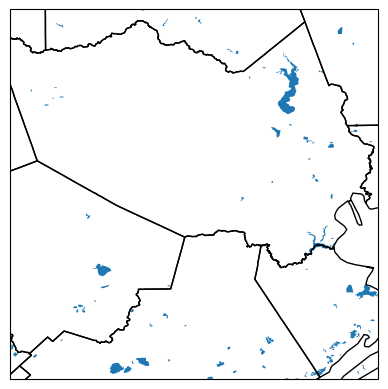

In [ ]:
#Let's plot all the polygons
import cartopy
ax = plt.axes(projection = cartopy.crs.PlateCarree())
ax.add_geometries(fp.geometry, crs = cartopy.crs.PlateCarree()) # for Lat/Lon data.

#Let's superimpose the county boundaries on top to know what we are looking at
fp2 = gpd.read_file('/scratch/eeps440/data/HW/HW2/Tx_CntyBndry_Detail_TIGER500k.shp')
ax.add_geometries(fp2.geometry, crs = cartopy.crs.PlateCarree(),facecolor='none',edgecolor = 'black') # for Lat/Lon data.
#Extract the boundaries
bounds = fp.total_bounds
#Use the boundaries to define the map extent
ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]])
#Let's look at the geometry of the data
plt.show()

# Plot the data for George Lake

In [54]:
#Let's only look at George Lake
george_lake = fp.loc[fp.Lake_name == 'Lake George']
george_lake

,Hylak_id,Lake_name,Country,Continent,Poly_src,Lake_type,Grand_id,Lake_area,Shore_len,Shore_dev,...,Dis_avg,Res_time,Elevation,Slope_100,Wshd_area,Pour_long,Pour_lat,Shape_Leng,Shape_Area,geometry
6,114134,Lake George,United States of America,North America,SWBD,2,1306,8.86,15.09,1.43,...,0.937,285.299988,19,0.8,73.199997,-95.658496,29.478916,0.146676,0.000823,"POLYGON ((-95.65362 29.50446, -95.65344 29.499..."


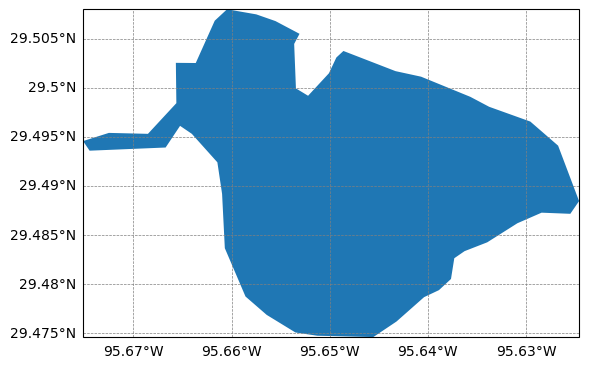

In [55]:
#Let's look at the geometry of the data

ax = plt.axes(projection = cartopy.crs.PlateCarree())
ax.add_geometries(george_lake.geometry, crs = cartopy.crs.PlateCarree()) # for Lat/Lon data.
bounds = george_lake.total_bounds
ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]])

gridlines = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gridlines.top_labels = False   # Hide top labels
gridlines.right_labels = False # Hide right labels

plt.show()

# George Lake: Summary statistics

In [56]:
#Print the area of the polygon
print(george_lake.area)

#Print the length of the polygon
print(george_lake.length)

#Compute the bounding box
print(george_lake.bounds)

6    0.000823
dtype: float64
6    0.146676
dtype: float64
        minx       miny       maxx       maxy
6 -95.675133  29.474583 -95.624589  29.507985


/var/folders/jz/5rrrpmh56qj6m6zb5v6w39kh0000gn/T/ipykernel_24029/2926645110.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(george_lake.area)
/var/folders/jz/5rrrpmh56qj6m6zb5v6w39kh0000gn/T/ipykernel_24029/2926645110.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print(george_lake.length)


What do the length and area even mean?

# Reproject to equal area

### Albers Equal-Area Conic
* +lat_1=29.5 +lat_2=45.5 → Standard parallels suitable for North America.
* +lat_0=29.7604 → Centered on Houston.
* +lon_0=-95.3698 → Central longitude set to Houston.

In [57]:
george_lake_ea = george_lake.to_crs("+proj=aea +lat_1=29.5 +lat_2=45.5 +lat_0=29.7604 +lon_0=-95.3698 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs")

In [58]:
#Print the area of the polygon
print(george_lake_ea.area)

#Print the length of the polygon
print(george_lake_ea.length)

#Compute the bounding box
print(george_lake_ea.bounds)

6    8.846659e+06
dtype: float64
6    15085.043222
dtype: float64
           minx          miny          maxx          maxy
6 -29608.940014 -31650.966663 -24709.325711 -27944.380175


## Create a buffer around lake

In [59]:
# Create 500m buffer zones around features
george_lake_ea["buffered"] = george_lake_ea.geometry.buffer(500)

# Shapely: Make your own points, lines, and polygons

In [60]:
import shapely

p1 = shapely.geometry.Point(-95.65, 29.49)
p2 = shapely.geometry.Point(-96.00, 29.52)
print(p1)
print(p2)

POINT (-95.65 29.49)
POINT (-96 29.52)


## Is my point within George Lake?

In [61]:
# Is my point within the George Lake polygon?
print(george_lake.geometry.contains(p1))
print(george_lake.geometry.contains(p2))

6    True
dtype: bool
6    False
dtype: bool


# Computational geometry for GIS

In [62]:
%%HTML
<iframe src='https://shapely.readthedocs.io/en/latest/manual.html#general-attributes-and-methods', width=700, height=600></iframe>

# Computational geometry is amazing (and very hard)

But it is not the purpose of this course.

Further interest?

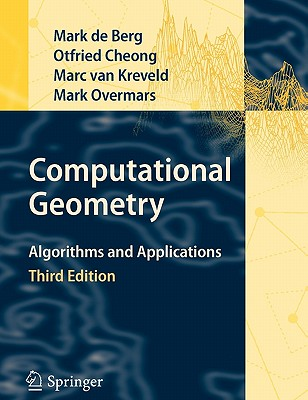

# To finish... If you want to get fancier you can superimpose the polygons on other data (e.g., elevation)

In [ ]:
%%bash 
# Using EPSG Definition
gdalwarp -overwrite -te -95.9 29.2 -94.9 30.2 -t_srs EPSG:4326 /scratch/eeps440/data/NED/NED.vrt ../Workspace/dem_houston.tif
# OR PROJ definition
#gdalwarp -overwrite -te -95.9 29.2 -94.9 30.2 -t_srs "+proj=longlat +datum=WGS84 +no_defs" /scratch/eeps440/data/NED/NED.vrt ../Workspace/dem_houston.tif

shell-init: error retrieving current directory: getcwd: cannot access parent directories: Inappropriate ioctl for device


Creating output file that is 3600P x 3600L.
Using internal nodata values (e.g. -99999) for image ../data/NED/NED.vrt.
Copying nodata values from source ../data/NED/NED.vrt to destination ../Workspace/dem_houston.tif.
Processing ../data/NED/NED.vrt [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.


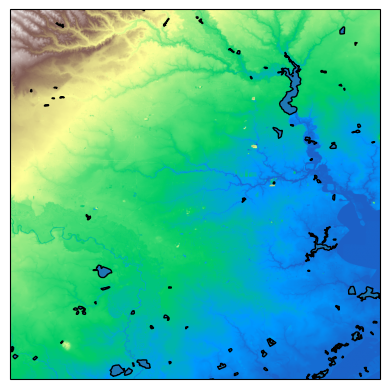

In [64]:
#Make the combined plot
dem = rasterio.open('../Workspace/dem_houston.tif').read(1)
lakes = cartopy.io.shapereader.Reader('../Workspace/HydroLakes_Houston.shp').geometries()
img_extent = [-95.9,-94.9,29.2,30.2]
ax = plt.axes(projection=cartopy.crs.PlateCarree())
plt.imshow(dem,transform=cartopy.crs.PlateCarree(),cmap=plt.get_cmap('terrain'),extent=(img_extent))
ax.add_feature(cartopy.feature.ShapelyFeature(lakes,cartopy.crs.PlateCarree(), edgecolor='black'))
plt.show()